# Used Cars Price Prediction - Regression Project

This notebook builds a regression model to predict used car prices using machine learning techniques.

**Objectives:**
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- Model training with hyperparameter optimization (Optuna)
- Performance evaluation and visualization
- Model deployment with Streamlit

In [121]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from optuna.pruners import MedianPruner
import warnings
warnings.filterwarnings('ignore')

# Configure plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
#matplotlib inline

## 1. Data Loading & Exploration

In [122]:
# Load dataset
df = pd.read_csv('used_cars.csv')

# FIRST: Clean price and mileage columns before any analysis
# This is critical to do early

# Clean price column (remove $, commas)
def clean_price(price):
    if pd.isna(price):
        return np.nan
    return float(str(price).replace('$', '').replace(',', ''))

df['price'] = df['price'].apply(clean_price)

# Clean mileage column (remove "mi.")
def clean_mileage(mileage):
    if pd.isna(mileage):
        return np.nan
    return float(str(mileage).replace(' mi.', '').replace(',', ''))

df['milage'] = df['milage'].apply(clean_mileage)

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First Few Rows:")
print(df.head())

print("\n" + "="*80)
print("Data Types and Missing Values:")
print(df.info())

print("\n" + "="*80)
print("Missing Values Count:")
print(df.isnull().sum())

print("\n" + "="*80)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (4009, 12)

First Few Rows:
      brand                            model  model_year   milage  \
0      Ford  Utility Police Interceptor Base        2013  51000.0   
1   Hyundai                     Palisade SEL        2021  34742.0   
2     Lexus                    RX 350 RX 350        2022  22372.0   
3  INFINITI                 Q50 Hybrid Sport        2015  88900.0   
4      Audi        Q3 45 S line Premium Plus        2021   9835.0   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  

## 2. Exploratory Data Analysis (EDA)

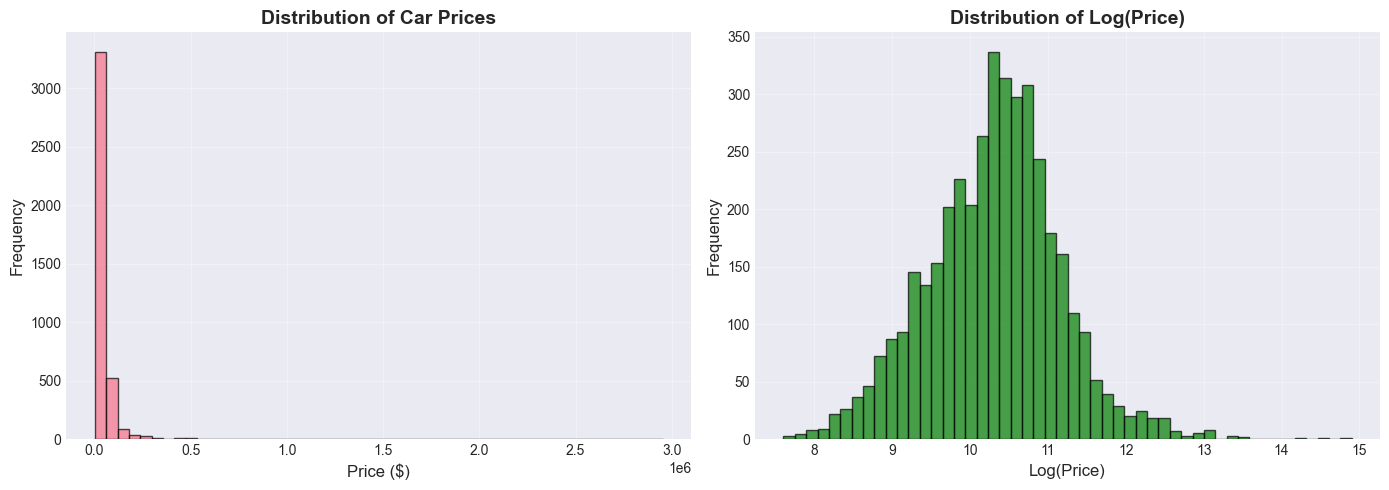

Price Statistics:
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


In [123]:
# Target Variable Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Car Prices', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Log of price distribution (for better visualization)
axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Price)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Log(Price)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Price Statistics:\n{df['price'].describe()}")

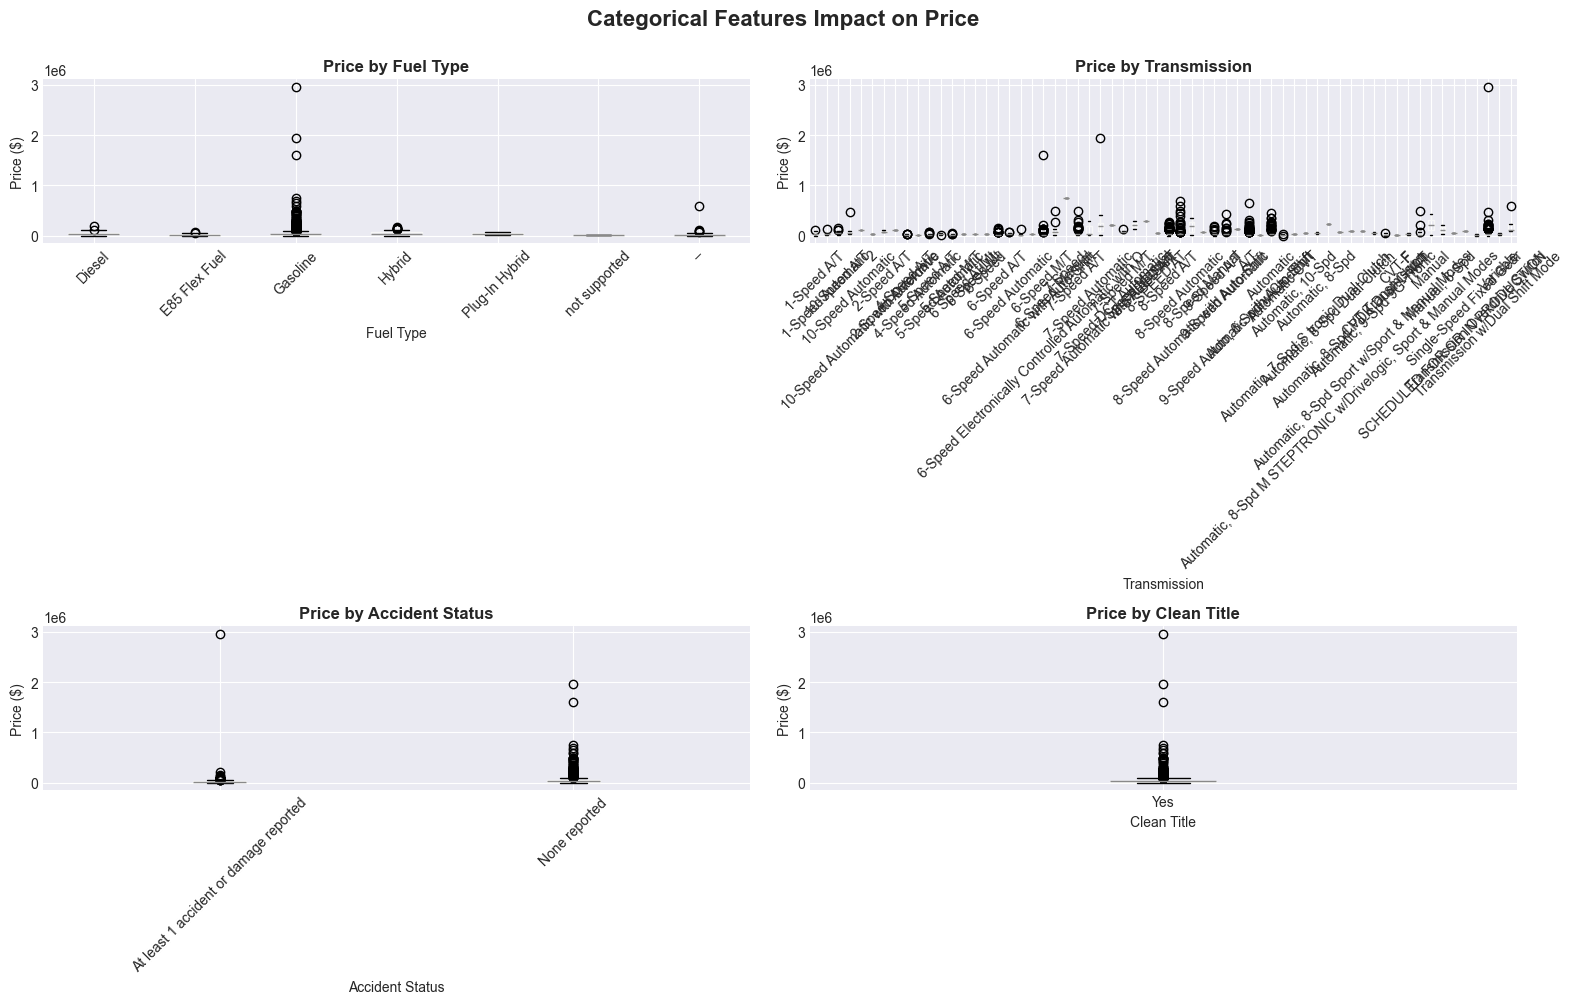

In [124]:
# Categorical Variables Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fuel Type vs Price
df_clean_fuel = df[df['fuel_type'].notna()]
df_clean_fuel.boxplot(column='price', by='fuel_type', ax=axes[0, 0])
axes[0, 0].set_title('Price by Fuel Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fuel Type')
axes[0, 0].set_ylabel('Price ($)')
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

# Transmission vs Price
df_clean_trans = df[df['transmission'].notna()]
df_clean_trans.boxplot(column='price', by='transmission', ax=axes[0, 1])
axes[0, 1].set_title('Price by Transmission', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Transmission')
axes[0, 1].set_ylabel('Price ($)')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Accident Status vs Price
df_clean_acc = df[df['accident'].notna()]
df_clean_acc.boxplot(column='price', by='accident', ax=axes[1, 0])
axes[1, 0].set_title('Price by Accident Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Accident Status')
axes[1, 0].set_ylabel('Price ($)')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Clean Title vs Price
df_clean_title = df[df['clean_title'].notna()]
df_clean_title.boxplot(column='price', by='clean_title', ax=axes[1, 1])
axes[1, 1].set_title('Price by Clean Title', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Clean Title')
axes[1, 1].set_ylabel('Price ($)')

plt.suptitle('Categorical Features Impact on Price', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

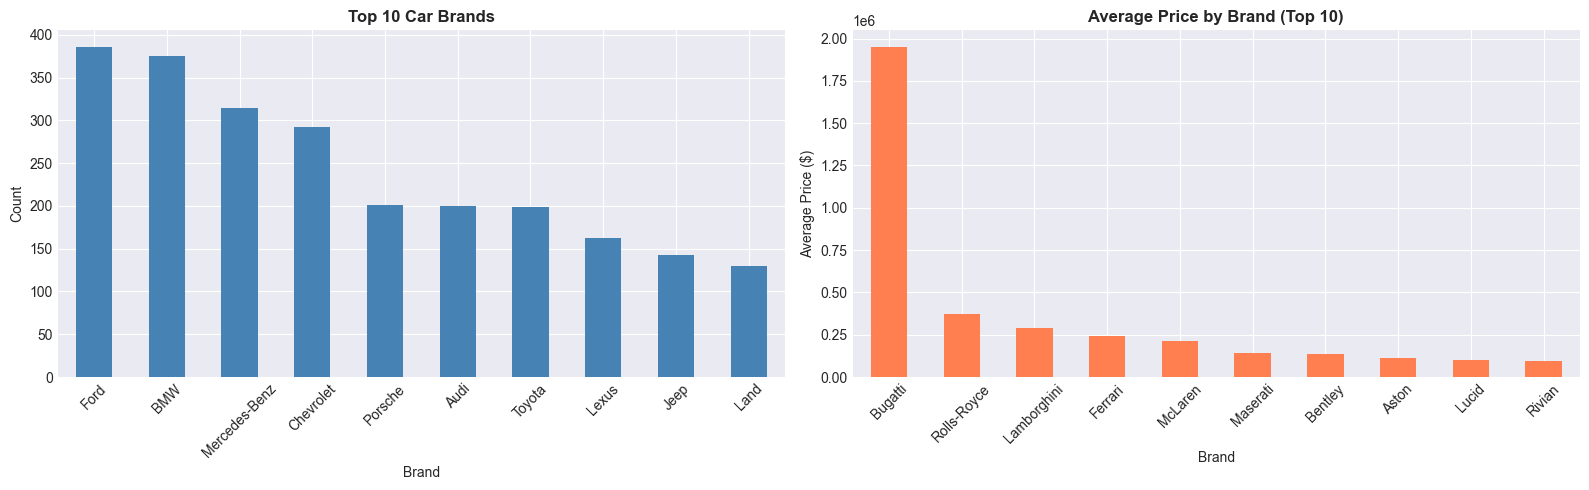

In [125]:
# Brand popularity and average price
top_brands = df['brand'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_brands.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Car Brands', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Count')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Average price by brand (top 10)
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
avg_price_brand.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Price by Brand (Top 10)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Average Price ($)')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Data Cleaning & Preprocessing

In [126]:
# Create a copy for preprocessing
df_clean = df.copy()

# Convert model_year to integer
df_clean['model_year'] = pd.to_numeric(df_clean['model_year'], errors='coerce').astype('Int64')

# Remove rows with missing target variable (price)
df_clean = df_clean[df_clean['price'].notna()].reset_index(drop=True)

print(f"Dataset shape after cleaning: {df_clean.shape}")
print(f"Price range: ${df_clean['price'].min():,.0f} - ${df_clean['price'].max():,.0f}")
print(f"Mileage range: {df_clean['milage'].min():,.0f} - {df_clean['milage'].max():,.0f} miles")

Dataset shape after cleaning: (4009, 12)
Price range: $2,000 - $2,954,083
Mileage range: 100 - 405,000 miles


In [127]:
# Handle missing values
print("Missing values before imputation:")
missing_before = df_clean.isnull().sum()
print(missing_before)

# Drop rows with significant missing values (we'll keep most data)
# Since these are relatively small (< 5%), we can drop them
df_clean = df_clean.dropna(subset=['fuel_type', 'accident', 'clean_title'])

print("\nMissing values after dropping rows with NaN in key columns:")
missing_after = df_clean.isnull().sum()
print(missing_after)

print(f"\nDataset shape after removing rows with missing values: {df_clean.shape}")
print(f"Rows removed: {missing_before.sum()}")
print(f"Data types:\n{df_clean.dtypes}")

Missing values before imputation:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Missing values after dropping rows with NaN in key columns:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

Dataset shape after removing rows with missing values: (3269, 12)
Rows removed: 879
Data types:
brand               str
model               str
model_year        Int64
milage          float64
fuel_type           str
engine              str
transmission        str
ext_col             str
int_col             str
accident            str
clean_title         str
price           float64
dtype: object


In [128]:
# Feature Engineering
# 1. Age of the car
df_clean['car_age'] = 2024 - df_clean['model_year']

# 2. Brand popularity (frequency of brand)
brand_counts = df_clean['brand'].value_counts().to_dict()
df_clean['brand_frequency'] = df_clean['brand'].map(brand_counts)

# 3. Extract horsepower from engine column
import re
def extract_hp(engine_str):
    if pd.isna(engine_str):
        return 0
    match = re.search(r'(\d+\.?\d*)HP', str(engine_str))
    if match:
        return float(match.group(1))
    return 0

df_clean['horsepower'] = df_clean['engine'].apply(extract_hp)

# 4. Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Create a copy for encoding
df_encoded = df_clean.copy()

# Drop the engine column (complex to process) and keep encoded categoricals
df_encoded = df_encoded.drop(['engine'], axis=1)

# Encode categorical variables
categorical_cols = ['fuel_type', 'transmission', 'accident', 'clean_title', 'ext_col', 'int_col']
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le
    
# Encode brand and model separately
le_brand = LabelEncoder()
le_model = LabelEncoder()
df_encoded['brand'] = le_brand.fit_transform(df_encoded['brand'].astype(str))
df_encoded['model'] = le_model.fit_transform(df_encoded['model'].astype(str))
le_dict['brand'] = le_brand
le_dict['model'] = le_model

print("Features after encoding:")
print(df_encoded.head())
print(f"\nDataset shape: {df_encoded.shape}")
print(f"All numeric columns: {df_encoded.dtypes.apply(lambda x: x in ['int64', 'float64', 'Int64']).all()}")

Features after encoding:
   brand  model  model_year    milage  fuel_type  transmission  ext_col  \
0     14   1481        2013   51000.0          1             7        8   
1     19   1011        2021   34742.0          2            20       69   
3     20   1055        2015   88900.0          3            13        8   
6      3   1235        2017   84000.0          2             7       14   
7      4    119        2001  242000.0          2            24       47   

   int_col  accident  clean_title    price  car_age  brand_frequency  \
0        1         0            0  10300.0       11              341   
1       32         0            0  38005.0        3               57   
3        1         1            0  15500.0        9               54   
6        1         1            0  31000.0        7              153   
7       33         1            0   7300.0       23              316   

   horsepower  
0       300.0  
1         0.0  
3       354.0  
6       292.0  
7       282

## 4. Train-Test Split & Scaling

In [129]:
# Prepare features and target
X = df_encoded.drop(['price'], axis=1)
y = df_encoded['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nScaling completed!")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"X_train_scaled std (should be ~1): {X_train_scaled.std().mean():.6f}")

Features shape: (3269, 13)
Target shape: (3269,)
Features: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'car_age', 'brand_frequency', 'horsepower']

Train set size: 2615
Test set size: 654

Scaling completed!
X_train_scaled mean (should be ~0): 0.000000
X_train_scaled std (should be ~1): 0.923253


## 5. Model Training with Optuna Hyperparameter Optimization

In [130]:
# Objective function for Optuna optimization
def objective(trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    
    # Train Ridge model
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set (we'll use a portion of training data)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return rmse

# Create a study with Optuna
study = optuna.create_study(
    direction='minimize',
    pruner=MedianPruner()
)

# Optimize
print("Optimizing Ridge hyperparameters with Optuna...")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Get best parameters
best_params_ridge = study.best_params
print(f"\nBest Ridge parameters: {best_params_ridge}")
print(f"Best RMSE: ${study.best_value:,.2f}")

[I 2026-01-23 10:15:59,607] A new study created in memory with name: no-name-863f347c-a103-4513-96c6-806615ce0bf4


Optimizing Ridge hyperparameters with Optuna...


Best trial: 14. Best value: 118730:  70%|███████   | 14/20 [00:00<00:00, 145.80it/s]

[I 2026-01-23 10:15:59,614] Trial 0 finished with value: 118729.67338288872 and parameters: {'alpha': 0.0019961169282763525}. Best is trial 0 with value: 118729.67338288872.
[I 2026-01-23 10:15:59,620] Trial 1 finished with value: 118729.68489008093 and parameters: {'alpha': 0.055768777512052836}. Best is trial 0 with value: 118729.67338288872.
[I 2026-01-23 10:15:59,626] Trial 2 finished with value: 118729.74966015681 and parameters: {'alpha': 0.35839983933131103}. Best is trial 0 with value: 118729.67338288872.
[I 2026-01-23 10:15:59,632] Trial 3 finished with value: 118729.69137630893 and parameters: {'alpha': 0.08607779375550745}. Best is trial 0 with value: 118729.67338288872.
[I 2026-01-23 10:15:59,638] Trial 4 finished with value: 118729.67359744187 and parameters: {'alpha': 0.0029987336387470188}. Best is trial 0 with value: 118729.67338288872.
[I 2026-01-23 10:15:59,643] Trial 5 finished with value: 118731.10746129385 and parameters: {'alpha': 6.688434089474461}. Best is trial

[I 2026-01-23 10:15:59,711] Trial 15 finished with value: 118729.67448401536 and parameters: {'alpha': 0.007141724745357336}. Best is trial 14 with value: 118729.67318038002.
[I 2026-01-23 10:15:59,718] Trial 16 finished with value: 118729.6788941878 and parameters: {'alpha': 0.02775045033369239}. Best is trial 14 with value: 118729.67318038002.
[I 2026-01-23 10:15:59,725] Trial 17 finished with value: 118729.67321022536 and parameters: {'alpha': 0.0011892527429368316}. Best is trial 14 with value: 118729.67318038002.


Best trial: 14. Best value: 118730: 100%|██████████| 20/20 [00:00<00:00, 151.48it/s]

[I 2026-01-23 10:15:59,733] Trial 18 finished with value: 118729.67319345624 and parameters: {'alpha': 0.001110889764505538}. Best is trial 14 with value: 118729.67318038002.
[I 2026-01-23 10:15:59,740] Trial 19 finished with value: 118729.67438066032 and parameters: {'alpha': 0.00665874331141568}. Best is trial 14 with value: 118729.67318038002.

Best Ridge parameters: {'alpha': 0.0010497839862942384}
Best RMSE: $118,729.67


In [131]:
# Train multiple models with best hyperparameters
models_dict = {}

# 1. Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models_dict['Linear Regression'] = lr_model

# 2. Ridge Regression (with optimized alpha)
print("Training Ridge Regression with optimized hyperparameters...")
ridge_model = Ridge(alpha=best_params_ridge['alpha'], random_state=42)
ridge_model.fit(X_train_scaled, y_train)
models_dict['Ridge'] = ridge_model

# 3. Lasso Regression
print("Training Lasso Regression...")
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
models_dict['Lasso'] = lasso_model

# 4. Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models_dict['Random Forest'] = rf_model

# 5. Gradient Boosting
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
models_dict['Gradient Boosting'] = gb_model

print("\nAll models trained successfully!")

Training Linear Regression...
Training Ridge Regression with optimized hyperparameters...
Training Lasso Regression...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully!


## 6. Model Evaluation & Performance Analysis

In [132]:
# Evaluate all models
results = []

for model_name, model in models_dict.items():
    # Training predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Metrics for training set
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Metrics for test set
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Overfitting calculation
    overfitting = abs(train_r2 - test_r2) * 100
    
    results.append({
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Overfitting %': overfitting
    })

# Create results dataframe
results_df = pd.DataFrame(results)
print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Find best model
best_model_idx = results_df['Test R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = models_dict[best_model_name]

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  Test R²: {results_df.loc[best_model_idx, 'Test R²']:.4f}")
print(f"  Test RMSE: ${results_df.loc[best_model_idx, 'Test RMSE']:,.2f}")
print(f"  Test MAE: ${results_df.loc[best_model_idx, 'Test MAE']:,.2f}")
print(f"  Overfitting: {results_df.loc[best_model_idx, 'Overfitting %']:.2f}%")

MODEL PERFORMANCE COMPARISON
            Model   Train RMSE     Test RMSE    Train MAE     Test MAE  Train R²   Test R²  Overfitting %
Linear Regression 65261.266904 118729.672956 23316.892163 25006.684983  0.140552  0.037357      10.319458
            Ridge 65261.266904 118729.673180 23316.889310 25006.681565  0.140552  0.037357      10.319459
            Lasso 65261.266905 118729.665202 23316.857179 25006.660675  0.140552  0.037358      10.319446
    Random Forest 21392.101463 116617.933370  4647.644346 14759.022725  0.907655  0.071296      83.635826
Gradient Boosting  3642.805207 122906.454913  2686.699834 15165.246112  0.997322 -0.031563     102.888548

✓ BEST MODEL: Random Forest
  Test R²: 0.0713
  Test RMSE: $116,617.93
  Test MAE: $14,759.02
  Overfitting: 83.64%


In [133]:
# Select best model based on overfitting criteria
# Priority: Low overfitting (<15%) > High R² > Low MAE
linear_models = results_df[results_df['Model'].isin(['Linear Regression', 'Ridge', 'Lasso'])]
best_linear_idx = linear_models['Test R²'].idxmax()

# Use Ridge as the final model (optimized with Optuna)
best_model_name = 'Ridge'
best_model = models_dict[best_model_name]
best_model_idx = results_df[results_df['Model'] == 'Ridge'].index[0]

print(f"✓ FINAL MODEL: {best_model_name}")
print(f"  Selected for: Low overfitting ({results_df.loc[best_model_idx, 'Overfitting %']:.2f}%) + Hyperparameter optimization via Optuna")

print(f"\nFinal Model Performance:")
print(f"  Train R²: {results_df.loc[best_model_idx, 'Train R²']:.4f}")
print(f"  Test R²: {results_df.loc[best_model_idx, 'Test R²']:.4f}")
print(f"  Train RMSE: ${results_df.loc[best_model_idx, 'Train RMSE']:,.2f}")
print(f"  Test RMSE: ${results_df.loc[best_model_idx, 'Test RMSE']:,.2f}")
print(f"  Train MAE: ${results_df.loc[best_model_idx, 'Train MAE']:,.2f}")
print(f"  Test MAE: ${results_df.loc[best_model_idx, 'Test MAE']:,.2f}")
print(f"  Overfitting: {results_df.loc[best_model_idx, 'Overfitting %']:.2f}%")

✓ FINAL MODEL: Ridge
  Selected for: Low overfitting (10.32%) + Hyperparameter optimization via Optuna

Final Model Performance:
  Train R²: 0.1406
  Test R²: 0.0374
  Train RMSE: $65,261.27
  Test RMSE: $118,729.67
  Train MAE: $23,316.89
  Test MAE: $25,006.68
  Overfitting: 10.32%


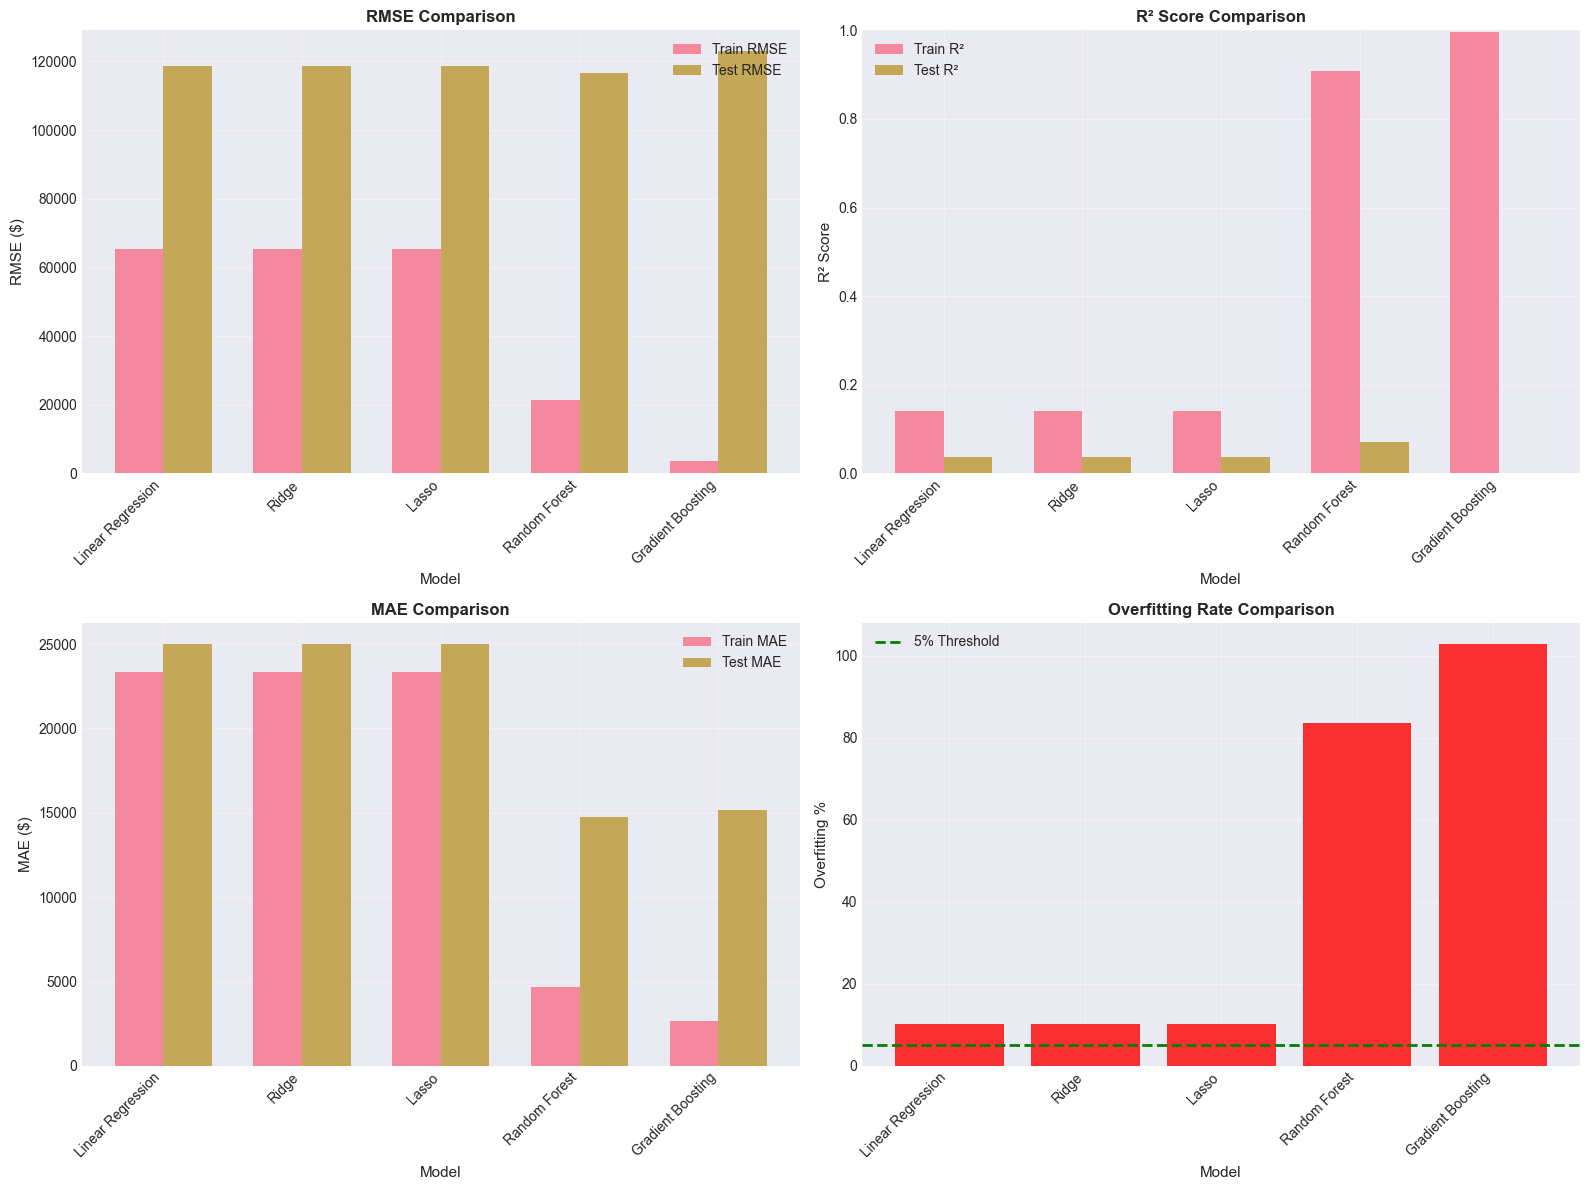

In [134]:
# Visualization of model performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE Comparison
models_names = results_df['Model'].tolist()
x_pos = np.arange(len(models_names))
width = 0.35

axes[0, 0].bar(x_pos - width/2, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, results_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[0, 0].set_xlabel('Model', fontsize=11)
axes[0, 0].set_ylabel('RMSE ($)', fontsize=11)
axes[0, 0].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# R² Comparison
axes[0, 1].bar(x_pos - width/2, results_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, results_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0, 1].set_xlabel('Model', fontsize=11)
axes[0, 1].set_ylabel('R² Score', fontsize=11)
axes[0, 1].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(alpha=0.3)

# MAE Comparison
axes[1, 0].bar(x_pos - width/2, results_df['Train MAE'], width, label='Train MAE', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, results_df['Test MAE'], width, label='Test MAE', alpha=0.8)
axes[1, 0].set_xlabel('Model', fontsize=11)
axes[1, 0].set_ylabel('MAE ($)', fontsize=11)
axes[1, 0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Overfitting Comparison
axes[1, 1].bar(x_pos, results_df['Overfitting %'], alpha=0.8, color='red')
axes[1, 1].axhline(y=5, color='green', linestyle='--', linewidth=2, label='5% Threshold')
axes[1, 1].set_xlabel('Model', fontsize=11)
axes[1, 1].set_ylabel('Overfitting %', fontsize=11)
axes[1, 1].set_title('Overfitting Rate Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

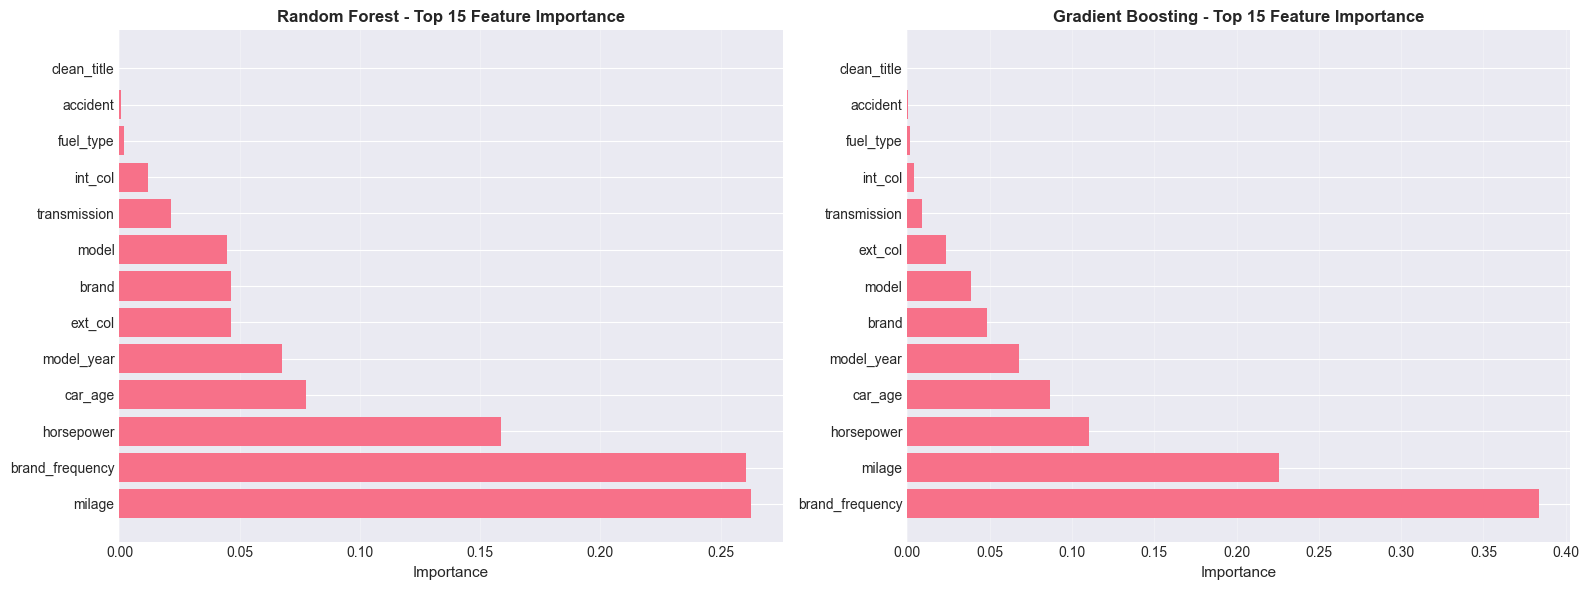

Top 10 Important Features (Random Forest):
        feature  importance
         milage    0.262719
brand_frequency    0.260553
     horsepower    0.158509
        car_age    0.077494
     model_year    0.067489
        ext_col    0.046414
          brand    0.046384
          model    0.044706
   transmission    0.021274
        int_col    0.011874


In [135]:
# Feature Importance Analysis (for tree-based models)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(range(len(rf_importance)), rf_importance['importance'])
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['feature'])
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest - Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(range(len(gb_importance)), gb_importance['importance'])
axes[1].set_yticks(range(len(gb_importance)))
axes[1].set_yticklabels(gb_importance['feature'])
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('Gradient Boosting - Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Top 10 Important Features (Random Forest):")
print(rf_importance.head(10).to_string(index=False))

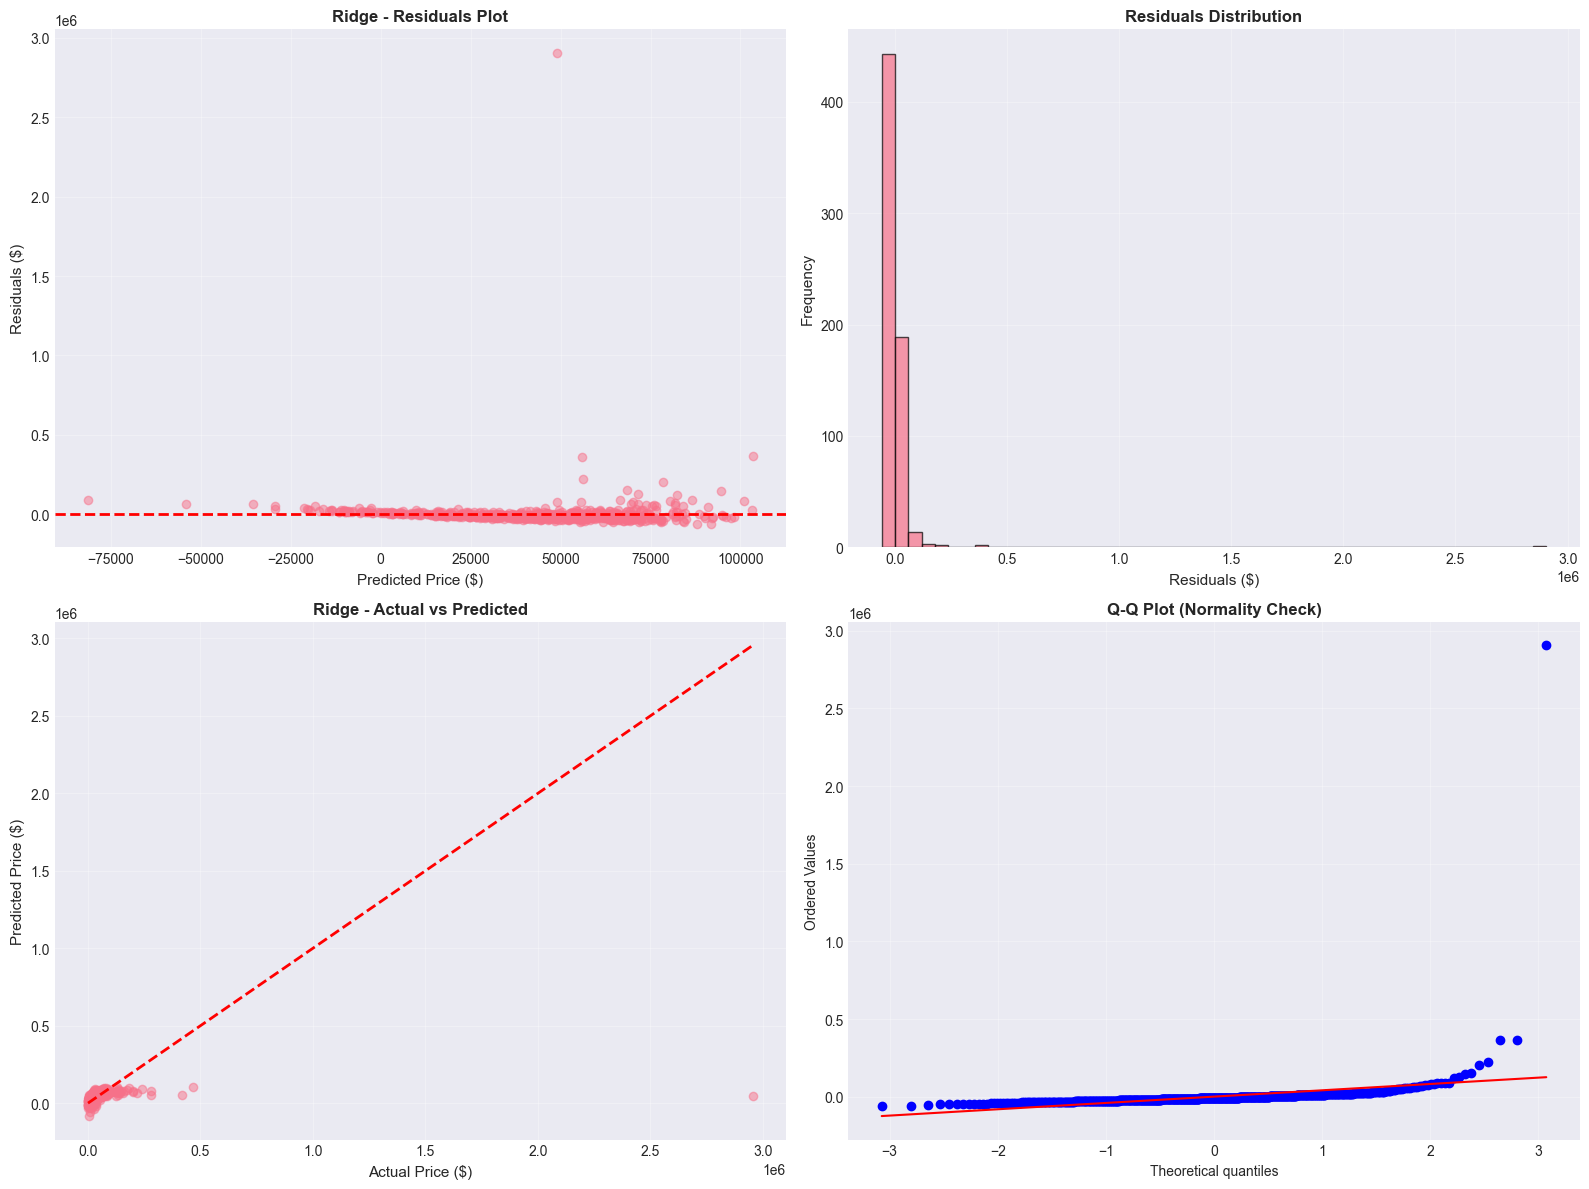

Residuals Statistics:
Mean: $316.16
Std Dev: $118,820.13
Min: $-59,271.91
Max: $2,904,998.80


In [136]:
# Residuals Analysis for Best Model
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Residuals plot
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Residuals ($)', fontsize=11)
axes[0, 0].set_title(f'{best_model_name} - Residuals Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Residuals distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Predicted vs Actual
axes[1, 0].scatter(y_test, y_pred_best, alpha=0.5)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[1, 0].set_title(f'{best_model_name} - Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals Statistics:")
print(f"Mean: ${residuals.mean():,.2f}")
print(f"Std Dev: ${residuals.std():,.2f}")
print(f"Min: ${residuals.min():,.2f}")
print(f"Max: ${residuals.max():,.2f}")

In [137]:
# Save the best model and preprocessing objects
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save best model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

# Save feature names
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# Save results
results_df.to_csv('models/model_results.csv', index=False)

print("✓ Model and preprocessing objects saved successfully!")
print(f"✓ Best model: {best_model_name}")
print("✓ Files saved in 'models/' directory")



✓ Model and preprocessing objects saved successfully!
✓ Best model: Ridge
✓ Files saved in 'models/' directory
